In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import numpy as np
from scipy import linalg as la
from matplotlib import pyplot as plt
import matplotlib

from tai_localizer.lauralizer import amorphous_model_BHZ_2D as am
from tai_localizer.perulizer import proximity_bonds

from koala.lattice import Lattice
from koala import pointsets
from koala import plotting as pl
import kwant as k

In [12]:
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

# Part 1

In [111]:
# make the amrphous lattice
L = 10
sigma = 0 * 1 / L
radius = np.sqrt(2) / L - 0.0001

points = pointsets.grid(L, L)
points = pointsets.move_all_points(points, sigma, sigma, 8)

e, c = proximity_bonds(points, radius)

not_crossing = np.abs(c).sum(axis=1) == 0

lattice = Lattice(points, e[not_crossing], c[not_crossing])

<Axes: >

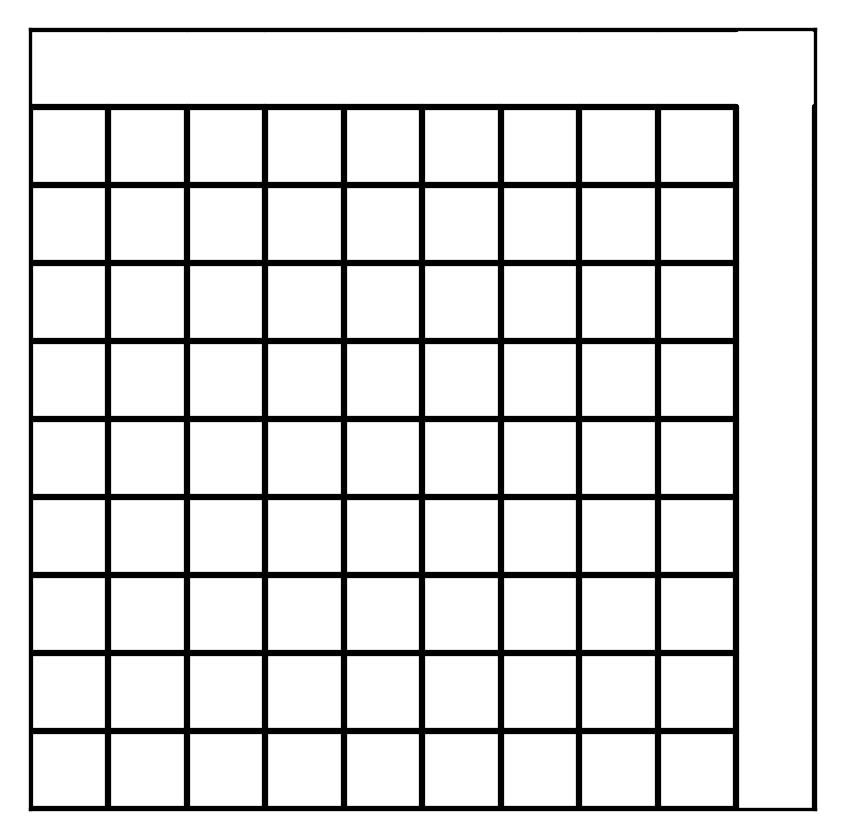

In [112]:
# plot the lattice to check

fig, ax = plt.subplots(figsize=(aps_halfwidth, aps_halfwidth), dpi=300)


ax.set_xticks([])
ax.set_yticks([])

# plt.scatter(*points.T)
pl.plot_edges(lattice)


/Users/laura/Desktop/TAI-localizer/src/tai_localizer/lauralizer/functions.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  matrix_f = np.asarray(K, dtype=np.float64, order="F")


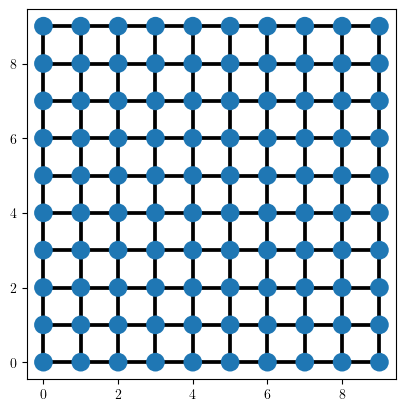

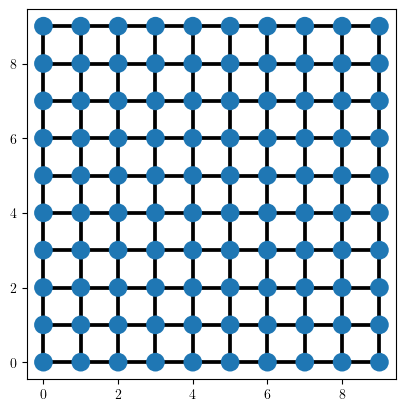

In [113]:
from tai_localizer.lauralizer.amorphous_model_BHZ_2D import amorph_BHZ
import tai_localizer
from importlib import reload
import tai_localizer.lauralizer

from tai_localizer.lauralizer.localizer import spectral_localizer_AII2D,invariant_localizer

system = amorph_BHZ(points * L, e[not_crossing])


def parameters_to_observables(system, A, B, Delta, dis_onsite, dis_hadamard):

    rng = np.random.default_rng()
    par_dict = {
        "norbs": 4,
        "rng_hdmd": rng,
        "Delta": Delta,
        "dis_hadamard": dis_hadamard * 100,
        "mu": 0,
        "A": A,
        "B": B,
        "rng_W": rng,
        "dis_onsite": dis_onsite,
    }
    fsyst = system.finalized()
    ham = fsyst.hamiltonian_submatrix(params=par_dict, sparse=True)
    positions = [site.pos for site in fsyst.sites]
    loc_rotated = spectral_localizer_AII2D(np.array(positions),ham,0,0.1)
    inv_localizer = invariant_localizer(loc_rotated.todense())
    return inv_localizer

seed_onsite = 0
seed_hadamard = 0
rng_W = np.random.default_rng(int(seed_onsite))
rng_hdmd = np.random.default_rng(int(seed_hadamard))
# Delta = 10
B = 1
A = 1
dis_onsite = 0

inv_D = []
Delta_range = np.linspace(-2, 4.1, 50)
for Delta in Delta_range:

    x = parameters_to_observables(system, A, B, Delta, dis_onsite, 1)
    inv_D.append(x)

# check its right

k.plot(system)
# plt.show()

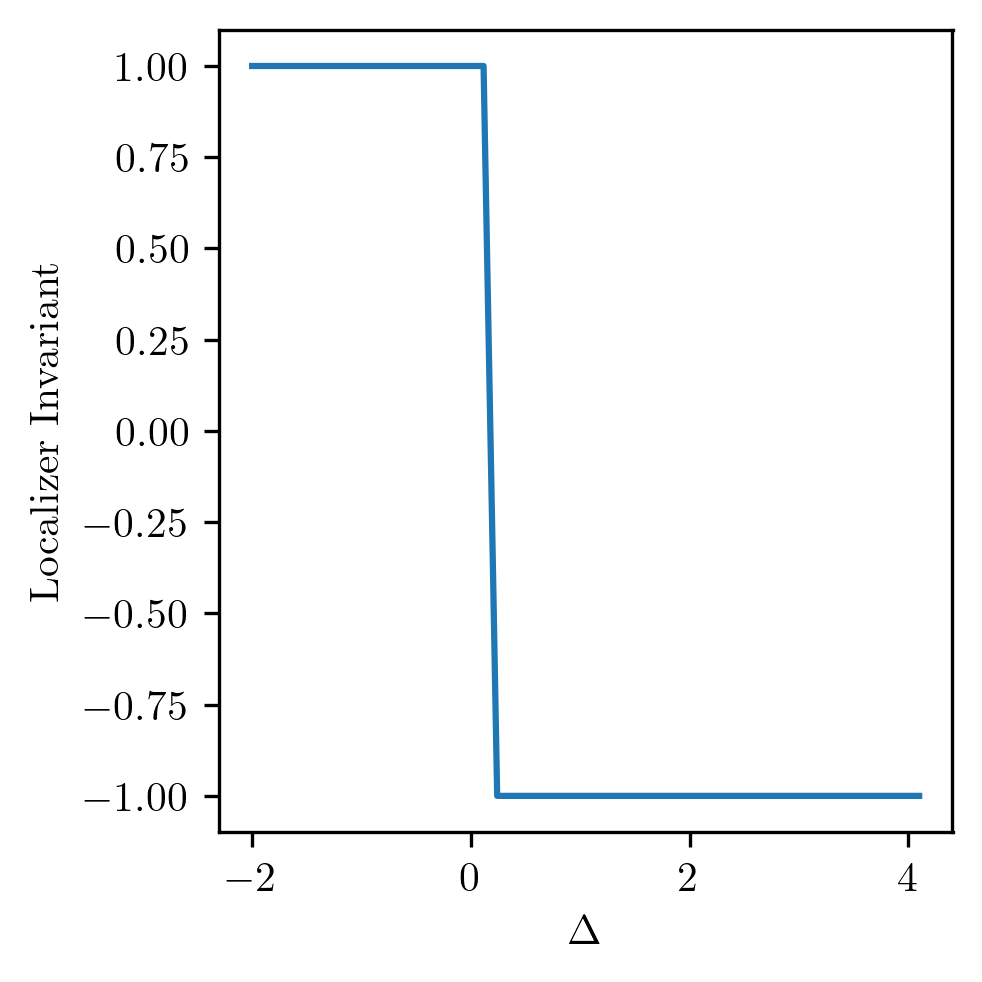

In [114]:
fig, ax = plt.subplots(figsize=(aps_halfwidth, aps_halfwidth), dpi=300)

ax.plot(Delta_range, inv_D)

ax.set_xlabel(r"$\Delta$")
ax.set_ylabel(r"Localizer Invariant")
plt.tight_layout()
plt.show()

# Part 2